# **Intro to Graph Theory - Colab 04 24.04.2026**

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.

With NetworkX you can load and store networks in standard and nonstandard data formats, generate many types of random and classic networks, analyze network structure, build network models, design new network algorithms, draw networks, and much more.

Library documentation: <a>https://networkx.org/documentation/stable/</a> .


# Setup

In [3]:
# Import the NetworkX package and some other may-be-useful packages
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Max-flow problem

Find a flow of maximum value and a  cut of minimum capacity.

Documentation: <a>https://networkx.org/documentation/stable/reference/algorithms/flow.html</a>

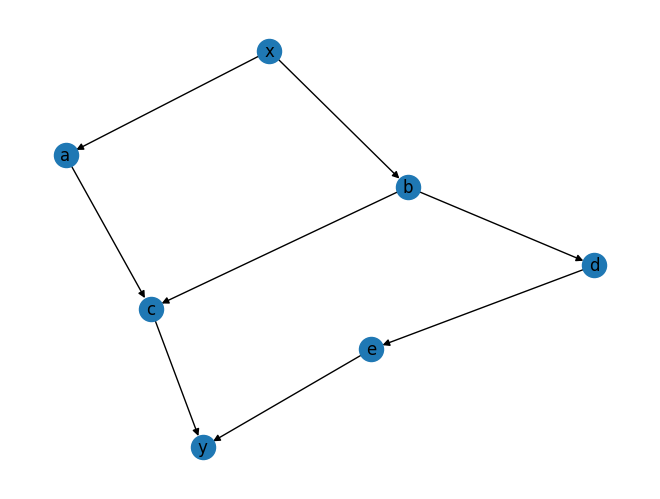

In [5]:
# Greate a network
G = nx.DiGraph()
G.add_edge("x", "a", capacity=3.0)
G.add_edge("x", "b", capacity=1.0)
G.add_edge("a", "c", capacity=3.0)
G.add_edge("b", "c", capacity=5.0)
G.add_edge("b", "d", capacity=4.0)
G.add_edge("d", "e", capacity=2.0)
G.add_edge("c", "y", capacity=2.0)
G.add_edge("e", "y", capacity=3.0)


nx.draw(G, with_labels=True)

In [6]:
flow_value, flow_dict = nx.maximum_flow(G, "x", "y")

print(f'Flow value: {flow_value}', f'Flow edges: {flow_dict}', sep='\n')
#flow of each edge

Flow value: 3.0
Flow edges: {'x': {'a': 2.0, 'b': 1.0}, 'a': {'c': 2.0}, 'b': {'c': 0, 'd': 1.0}, 'c': {'y': 2.0}, 'd': {'e': 1.0}, 'e': {'y': 1.0}, 'y': {}}


In [7]:
cut_value, partition = nx.minimum_cut(G, "x", "y")
reachable, non_reachable = partition

print(f'Cut value: {cut_value}', f'Reachable nodes from the source node: {reachable}', f'Nonreachable nodes from the source node: {non_reachable}', sep='\n')

Cut value: 3.0
Reachable nodes from the source node: {'c', 'x', 'a'}
Nonreachable nodes from the source node: {'y', 'b', 'd', 'e'}


In [35]:
# Read data from a txt file
flow_graph = pd.read_csv('flow_graph.txt', sep=' ', names=["from_node", "to_node", "capacity"])

flow_graph

,from_node,to_node,capacity
0,0,1,16
1,0,2,13
2,1,3,12
3,2,1,4
4,2,4,14
5,3,2,9
6,3,5,20
7,4,3,7
8,4,5,4


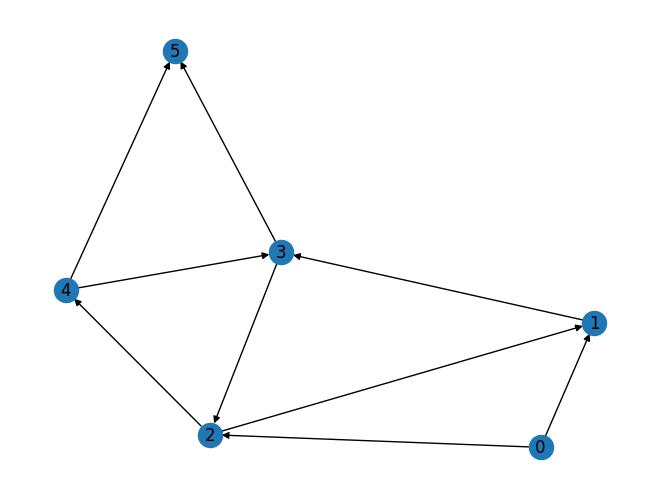

In [36]:
flow_edges = np.array(flow_graph)

F = nx.DiGraph()
F.add_weighted_edges_from(flow_edges)

# visualize a graph
pos = nx.spring_layout(F)
nx.draw(F,  pos, with_labels=True)

In [10]:
 # Not working!
nx.maximum_flow(F,0,5)

NetworkXUnbounded: Infinite capacity path, flow unbounded above.

In [14]:
# We have an attribute 'weight', not 'capacity'!
F[0][1]

{'weight': np.int64(16)}

In [15]:
caps = flow_graph['capacity']
caps

0    16
1    13
2    12
3     4
4    14
5     9
6    20
7     7
8     4
Name: capacity, dtype: int64

In [16]:
for (u, v, wt) in F.edges.data('weight'):
  F[u][v]['capacity'] = wt

In [17]:
for u, v in F.edges():
  cap = F[u][v]['capacity']
  print(f'Capacity of the edge ({u},{v}) is {cap}', sep='\n')

Capacity of the edge (0,1) is 16
Capacity of the edge (0,2) is 13
Capacity of the edge (1,3) is 12
Capacity of the edge (2,1) is 4
Capacity of the edge (2,4) is 14
Capacity of the edge (3,2) is 9
Capacity of the edge (3,5) is 20
Capacity of the edge (4,3) is 7
Capacity of the edge (4,5) is 4


In [18]:
# Now we have two features for each edge: 'weight' and 'capacity'
F[0][1]

{'weight': np.int64(16), 'capacity': np.int64(16)}

In [19]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 0, 5)

(np.int64(23),
 {np.int64(0): {np.int64(1): np.int64(12), np.int64(2): np.int64(11)},
  np.int64(1): {np.int64(3): np.int64(12)},
  np.int64(2): {np.int64(1): 0, np.int64(4): np.int64(11)},
  np.int64(3): {np.int64(2): 0, np.int64(5): np.int64(19)},
  np.int64(4): {np.int64(3): np.int64(7), np.int64(5): np.int64(4)},
  np.int64(5): {}})

### Exercise 1.

1. Greate a directed graph from a txt.file (flow_graph_1.txt, flow_graph_2.txt etc.)
2. Add a capacity attribute to each edge.
3. Let the source node (s) is node 1, the target node (t) is a node with largest number.
4. Solve a max-flow problem for the network with s and t.
5. Send your results for each graph in MS Teams chat messager.



In [2]:
# Read data from a txt file
flow_graph_1 = pd.read_csv('flow_graph_1.txt', sep=' ', names=["from_node", "to_node", "capacity"])

flow_graph_1

,from_node,to_node,capacity
0,1,2,48
1,1,3,35
2,1,4,213
3,1,5,213
4,1,6,213
5,1,7,213
6,2,1,199
7,2,3,58
8,2,4,35
9,2,5,213


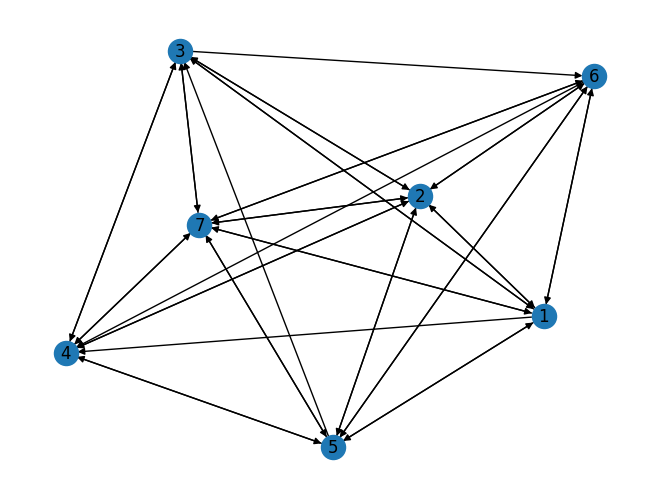

In [3]:
flow_edges = np.array(flow_graph_1)

F = nx.DiGraph()
F.add_weighted_edges_from(flow_edges)

# visualize a graph
pos = nx.spring_layout(F)
nx.draw(F,  pos, with_labels=True)

In [4]:
# We have an attribute 'weight', not 'capacity'!
F[1][2]

{'weight': np.int64(48)}

In [5]:
caps = flow_graph_1['capacity']
caps

0      48
1      35
2     213
3     213
4     213
5     213
6     199
7      58
8      35
9     213
10    213
11    213
12    138
13    199
14     58
15    213
16    213
17     58
18    199
19     58
20    213
21    213
22     35
23     58
24    164
25     10
26    213
27    213
28    213
29     10
30     24
31    213
32    213
33    213
34    213
35    213
36    213
37    213
Name: capacity, dtype: int64

In [6]:
for (u, v, wt) in F.edges.data('weight'):
  F[u][v]['capacity'] = wt

In [7]:
for u, v in F.edges():
  cap = F[u][v]['capacity']
  print(f'Capacity of the edge ({u},{v}) is {cap}', sep='\n')

Capacity of the edge (1,2) is 48
Capacity of the edge (1,3) is 35
Capacity of the edge (1,4) is 213
Capacity of the edge (1,5) is 213
Capacity of the edge (1,6) is 213
Capacity of the edge (1,7) is 213
Capacity of the edge (2,1) is 199
Capacity of the edge (2,3) is 58
Capacity of the edge (2,4) is 35
Capacity of the edge (2,5) is 213
Capacity of the edge (2,6) is 213
Capacity of the edge (2,7) is 213
Capacity of the edge (3,1) is 138
Capacity of the edge (3,2) is 199
Capacity of the edge (3,4) is 58
Capacity of the edge (3,6) is 213
Capacity of the edge (3,7) is 213
Capacity of the edge (4,2) is 58
Capacity of the edge (4,3) is 199
Capacity of the edge (4,5) is 58
Capacity of the edge (4,7) is 213
Capacity of the edge (5,1) is 213
Capacity of the edge (5,2) is 35
Capacity of the edge (5,3) is 58
Capacity of the edge (5,4) is 164
Capacity of the edge (5,6) is 10
Capacity of the edge (5,7) is 213
Capacity of the edge (6,1) is 213
Capacity of the edge (6,2) is 213
Capacity of the edge (6,

In [8]:
# Now we have two features for each edge: 'weight' and 'capacity'
F[1][2]

{'weight': np.int64(48), 'capacity': np.int64(48)}

In [9]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 1, 7)

(np.int64(935),
 {np.int64(1): {np.int64(2): np.int64(48),
   np.int64(3): np.int64(35),
   np.int64(4): np.int64(213),
   np.int64(5): np.int64(213),
   np.int64(6): np.int64(213),
   np.int64(7): np.int64(213)},
  np.int64(2): {np.int64(1): 0,
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(6): 0,
   np.int64(7): np.int64(48)},
  np.int64(3): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(4): 0,
   np.int64(6): 0,
   np.int64(7): np.int64(35)},
  np.int64(4): {np.int64(2): 0,
   np.int64(3): 0,
   np.int64(5): 0,
   np.int64(7): np.int64(213)},
  np.int64(5): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(6): 0,
   np.int64(7): np.int64(213)},
  np.int64(6): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(7): np.int64(213)},
  np.int64(7): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(6): 0}})

In [10]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 1, 5)

(np.int64(721),
 {np.int64(1): {np.int64(2): 0,
   np.int64(3): np.int64(35),
   np.int64(4): np.int64(213),
   np.int64(5): np.int64(213),
   np.int64(6): np.int64(213),
   np.int64(7): np.int64(213)},
  np.int64(2): {np.int64(1): np.int64(166),
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(5): np.int64(213),
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(3): {np.int64(1): 0,
   np.int64(2): np.int64(35),
   np.int64(4): 0,
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(4): {np.int64(2): np.int64(58),
   np.int64(3): 0,
   np.int64(5): np.int64(58),
   np.int64(7): np.int64(97)},
  np.int64(5): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(6): {np.int64(1): 0,
   np.int64(2): np.int64(189),
   np.int64(4): 0,
   np.int64(5): np.int64(24),
   np.int64(7): 0},
  np.int64(7): {np.int64(1): 0,
   np.int64(2): np.int64(97),
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(5): np.int64(213),
   np.int64

In [11]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 1, 2)

(np.int64(766),
 {np.int64(1): {np.int64(2): np.int64(48),
   np.int64(3): 0,
   np.int64(4): np.int64(213),
   np.int64(5): np.int64(213),
   np.int64(6): np.int64(213),
   np.int64(7): np.int64(213)},
  np.int64(2): {np.int64(1): 0,
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(3): {np.int64(1): np.int64(134),
   np.int64(2): np.int64(199),
   np.int64(4): 0,
   np.int64(6): np.int64(49),
   np.int64(7): 0},
  np.int64(4): {np.int64(2): np.int64(58),
   np.int64(3): np.int64(155),
   np.int64(5): 0,
   np.int64(7): 0},
  np.int64(5): {np.int64(1): 0,
   np.int64(2): np.int64(35),
   np.int64(3): np.int64(58),
   np.int64(4): 0,
   np.int64(6): np.int64(10),
   np.int64(7): np.int64(110)},
  np.int64(6): {np.int64(1): 0,
   np.int64(2): np.int64(213),
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(7): np.int64(59)},
  np.int64(7): {np.int64(1): 0,
   np.int64(2): np.int64(213),
   np.int64(3): np.int64(169),
   np.int64(4

In [12]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 1, 3)

(np.int64(563),
 {np.int64(1): {np.int64(2): 0,
   np.int64(3): np.int64(35),
   np.int64(4): np.int64(213),
   np.int64(5): np.int64(88),
   np.int64(6): np.int64(213),
   np.int64(7): np.int64(213)},
  np.int64(2): {np.int64(1): np.int64(199),
   np.int64(3): np.int64(58),
   np.int64(4): np.int64(35),
   np.int64(5): np.int64(134),
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(3): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(4): 0,
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(4): {np.int64(2): 0,
   np.int64(3): np.int64(199),
   np.int64(5): np.int64(49),
   np.int64(7): 0},
  np.int64(5): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(3): np.int64(58),
   np.int64(4): 0,
   np.int64(6): 0,
   np.int64(7): np.int64(213)},
  np.int64(6): {np.int64(1): 0,
   np.int64(2): np.int64(213),
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(7): 0},
  np.int64(7): {np.int64(1): 0,
   np.int64(2): np.int64(213),
   np.int64(3): np.int64(213),
   np.int64(4): 0,
   np.int64(5): 0

In [13]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 1, 4)

(np.int64(693),
 {np.int64(1): {np.int64(2): 0,
   np.int64(3): np.int64(35),
   np.int64(4): np.int64(213),
   np.int64(5): np.int64(213),
   np.int64(6): np.int64(213),
   np.int64(7): np.int64(213)},
  np.int64(2): {np.int64(1): np.int64(194),
   np.int64(3): np.int64(13),
   np.int64(4): np.int64(35),
   np.int64(5): 0,
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(3): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(4): np.int64(58),
   np.int64(6): np.int64(39),
   np.int64(7): 0},
  np.int64(4): {np.int64(2): 0,
   np.int64(3): 0,
   np.int64(5): 0,
   np.int64(7): 0},
  np.int64(5): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(3): np.int64(49),
   np.int64(4): np.int64(164),
   np.int64(6): 0,
   np.int64(7): 0},
  np.int64(6): {np.int64(1): 0,
   np.int64(2): np.int64(29),
   np.int64(4): np.int64(10),
   np.int64(5): 0,
   np.int64(7): np.int64(213)},
  np.int64(7): {np.int64(1): 0,
   np.int64(2): np.int64(213),
   np.int64(3): 0,
   np.int64(4): np.int64(213),
   np.i

In [14]:
# and we can solve max-flow problem!
nx.maximum_flow(F, 1, 6)

(np.int64(862),
 {np.int64(1): {np.int64(2): np.int64(48),
   np.int64(3): 0,
   np.int64(4): np.int64(213),
   np.int64(5): np.int64(213),
   np.int64(6): np.int64(213),
   np.int64(7): np.int64(213)},
  np.int64(2): {np.int64(1): 0,
   np.int64(3): np.int64(38),
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(6): np.int64(213),
   np.int64(7): 0},
  np.int64(3): {np.int64(1): np.int64(38),
   np.int64(2): 0,
   np.int64(4): 0,
   np.int64(6): np.int64(213),
   np.int64(7): 0},
  np.int64(4): {np.int64(2): np.int64(58),
   np.int64(3): np.int64(155),
   np.int64(5): 0,
   np.int64(7): 0},
  np.int64(5): {np.int64(1): 0,
   np.int64(2): np.int64(35),
   np.int64(3): np.int64(58),
   np.int64(4): 0,
   np.int64(6): np.int64(10),
   np.int64(7): np.int64(110)},
  np.int64(6): {np.int64(1): 0,
   np.int64(2): 0,
   np.int64(4): 0,
   np.int64(5): 0,
   np.int64(7): 0},
  np.int64(7): {np.int64(1): 0,
   np.int64(2): np.int64(110),
   np.int64(3): 0,
   np.int64(4): 0,
   np.int64(5): 0,

# Max-cardinality matching

Find max-cardinality matching in a bipartite graph.
$x_1y_1, x_1y_2, x_1y_3, x_2y_1, x_2y_2, x_2y_3, x_3y_1, x_3y_2$.

In [8]:
#Import the bipartite algorithms
from networkx.algorithms import bipartite

In [9]:
# Greate a bipartite graph
B=nx.Graph()
# Add nodes with the node attribute "bipartite"
B.add_nodes_from(["x1", "x2", "x3"], bipartite=0)
B.add_nodes_from(["y1", "y2", "y3"], bipartite=1)
# Add edges only between nodes of opposite node sets
B.add_edges_from([("x1","y1"),("x1","y2"),("x1","y3"),("x2","y1"),("x2","y2"),("x2","y3"),("x3","y1"),("x3","y2")])

In [10]:
subset_color = [
    "violet",
    "limegreen"
]
color = [subset_color[data["bipartite"]] for v, data in B.nodes(data=True)]
color

['violet', 'violet', 'violet', 'limegreen', 'limegreen', 'limegreen']

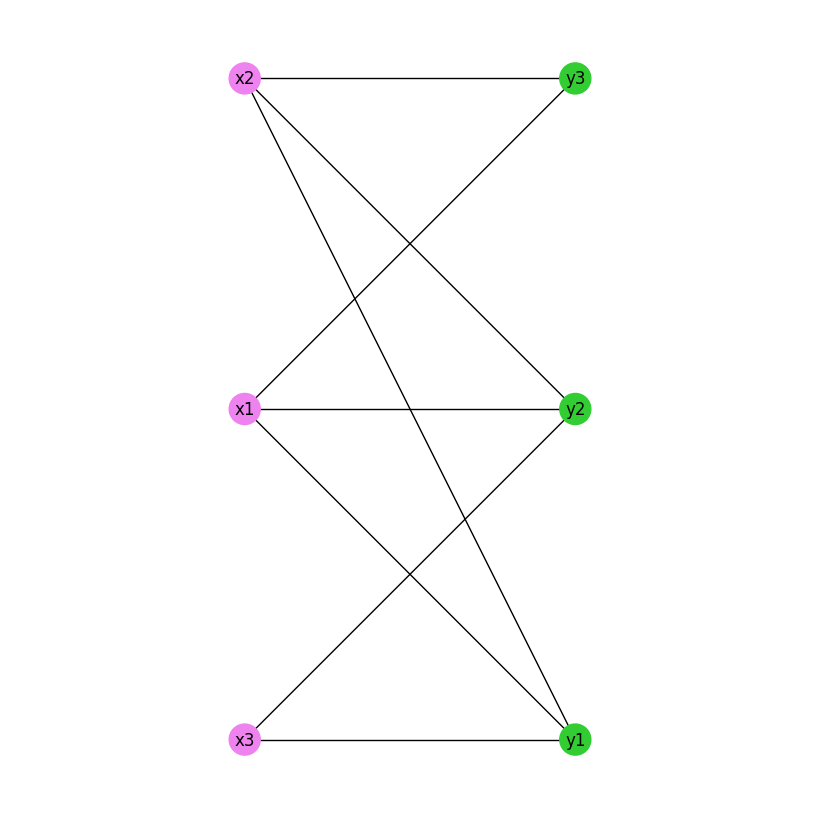

In [22]:
pos = nx.multipartite_layout(B, subset_key="bipartite")
plt.figure(figsize=(8, 8))
nx.draw(B, pos, with_labels=True, node_color=color, node_size=500)
plt.axis("equal")
plt.show()

In [23]:
# Find a maximum matching
nx.bipartite.maximum_matching(B)

{'x3': 'y1', 'x1': 'y2', 'x2': 'y3', 'y1': 'x3', 'y2': 'x1', 'y3': 'x2'}

In [24]:
# Solve a max-matching problem with the flow algorithm
DiB = nx.DiGraph()

L_nodes = ["x1", "x2", "x3"]
R_nodes = ["y1", "y2", "y3"]

DiB.add_edges_from([("x1","y1"),("x1","y2"),("x1","y3"),("x2","y1"),("x2","y2"),("x2","y3"),("x3","y1"),("x3","y2")])

In [25]:
# Add edges from s to L_nodes
for v in L_nodes:
  DiB.add_edge("s", v)

In [26]:
# Add edges from R_nodes to  t
for v in R_nodes:
  DiB.add_edge(v, "t")

In [27]:
# Add capacities to the graph edges


for u, v in DiB.edges():
  DiB[u][v]['capacity'] = 1

In [28]:
nx.maximum_flow(DiB, "s", "t")

(3,
 {'x1': {'y1': 0, 'y2': 0, 'y3': 1},
  'y1': {'t': 1},
  'y2': {'t': 1},
  'y3': {'t': 1},
  'x2': {'y1': 0, 'y2': 1, 'y3': 0},
  'x3': {'y1': 1, 'y2': 0},
  's': {'x1': 1, 'x2': 1, 'x3': 1},
  't': {}})

### Exercise 2.

Find max-cardinality matching in a bipartite graph with edges $x_1y_1, x_1y_5, x_2y_2, x_2y_4, x_3y_2, x_3y_4, x_4y_1, x_5y_2, x_5y_3$.
  * First, create a bipatite graph and apply a mathiching algorithm;
  * Then, create a directed graph (see lecture 5) and find a maximum flow;
  * Compare results obtained by two methods.

In [13]:
# Greate a bipartite graph
C=nx.Graph()
# Add nodes with the node attribute "bipartite"
C.add_nodes_from(["x1", "x2", "x3", "x4", "x5"], bipartite=0)
C.add_nodes_from(["y1", "y2", "y3", "y4", "y5"], bipartite=1)
# Add edges only between nodes of opposite node sets
C.add_edges_from([("x1","y1"),("x1","y5"),("x2","y2"),("x2","y4"),("x3","y2"),("x3","y4"),("x4","y1"),("x5","y2"),("x5","y3")])

In [14]:
subset_color = [
    "violet",
    "limegreen"
]
color = [subset_color[data["bipartite"]] for v, data in C.nodes(data=True)]
color

['violet',
 'violet',
 'violet',
 'violet',
 'violet',
 'limegreen',
 'limegreen',
 'limegreen',
 'limegreen',
 'limegreen']

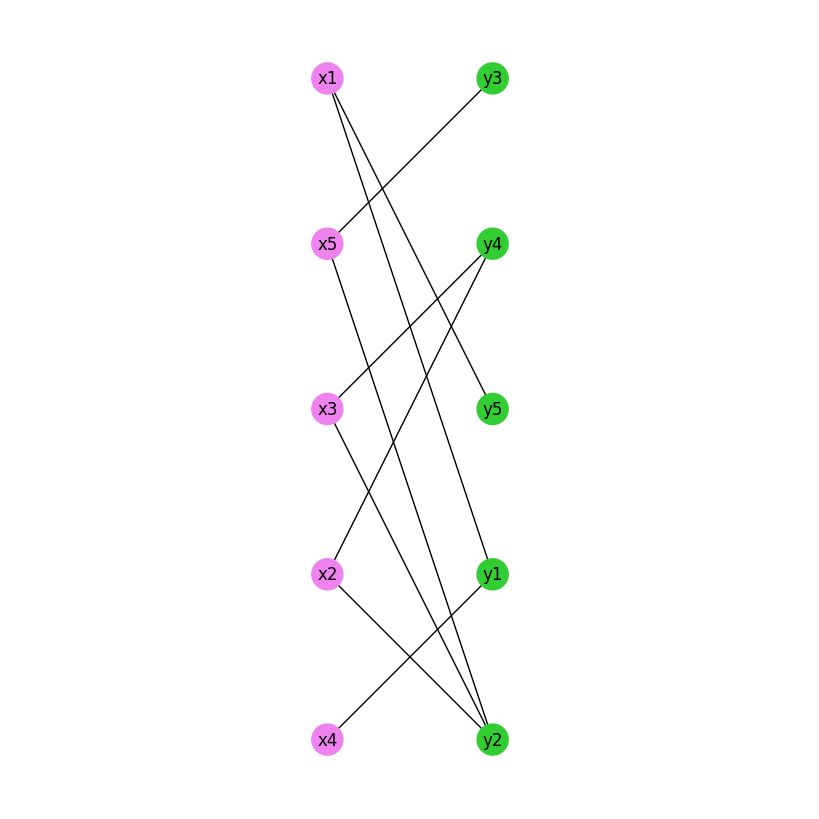

In [16]:
pos = nx.multipartite_layout(C, subset_key="bipartite")
plt.figure(figsize=(8, 8))
nx.draw(C, pos, with_labels=True, node_color=color, node_size=500)
plt.axis("equal")
plt.show()

In [18]:
# Solve a max-matching problem with the flow algorithm
DiC = nx.DiGraph()

L_nodes = ["x1", "x2", "x3", "x4", "x5"]
R_nodes = ["y1", "y2", "y3", "y4", "y5"]

DiC.add_edges_from([("x1","y1"),("x1","y5"),("x2","y2"),("x2","y4"),("x3","y2"),("x3","y4"),("x4","y1"),("x5","y2"),("x5","y3")])

In [19]:
# Add edges from s to L_nodes
for v in L_nodes:
  DiC.add_edge("s", v)

In [20]:
# Add edges from R_nodes to  t
for v in R_nodes:
  DiC.add_edge(v, "t")

In [21]:
# Add capacities to the graph edges


for u, v in DiC.edges():
  DiC[u][v]['capacity'] = 1

In [22]:
nx.maximum_flow(DiC, "s", "t")

(5,
 {'x1': {'y1': 0, 'y5': 1},
  'y1': {'t': 1},
  'y5': {'t': 1},
  'x2': {'y2': 1, 'y4': 0},
  'y2': {'t': 1},
  'y4': {'t': 1},
  'x3': {'y2': 0, 'y4': 1},
  'x4': {'y1': 1},
  'x5': {'y2': 0, 'y3': 1},
  'y3': {'t': 1},
  's': {'x1': 1, 'x2': 1, 'x3': 1, 'x4': 1, 'x5': 1},
  't': {}})

# Min-cost max flow

Documentation: <a>https://networkx.org/documentation/stable/reference/algorithms/flow.html</a> (see Network Simplex section)

In [24]:
G = nx.DiGraph()
G.add_edges_from(
    [
        (1, 2, {"capacity": 12, "weight": 4}),
        (1, 3, {"capacity": 20, "weight": 6}),
        (2, 3, {"capacity": 6, "weight": -3}),
        (2, 6, {"capacity": 14, "weight": 1}),
        (3, 4, {"weight": 9}),
        (3, 5, {"capacity": 10, "weight": 5}),
        (4, 2, {"capacity": 19, "weight": 13}),
        (4, 5, {"capacity": 4, "weight": 0}),
        (5, 7, {"capacity": 28, "weight": 2}),
        (6, 5, {"capacity": 11, "weight": 1}),
        (6, 7, {"weight": 8})
    ]
)

First, we find a maximum (s, t)-flow of minimum cost.

In [25]:
#  Find a maximum (s, t)-flow of minimum cost.
nx.max_flow_min_cost(G, 1, 7)

{1: {2: 12, 3: 16},
 2: {3: 0, 6: 14},
 3: {4: 6, 5: 10},
 6: {5: 11, 7: 3},
 4: {2: 2, 5: 4},
 5: {7: 25},
 7: {}}

In [26]:
#  Find a maximum (s, t)-flow of minimum cost.
mincostFlow = nx.max_flow_min_cost(G, 1, 7)

# Compute the value of the flow (sum of the flow on edges leaved the source s)
mincostFlowValue = sum((mincostFlow[1][u] for u in G.successors(1)))

# Compute the cost of the flow given by flowDict on graph G.
mincost = nx.cost_of_flow(G, mincostFlow)

print(f'Maximum flow value - {mincostFlowValue}; \nCost of a minimum cost maximum flow - {mincost}.')

Maximum flow value - 28; 
Cost of a minimum cost maximum flow - 373.


In [27]:
# Let's find a maximum flow (without considering costs)
maxFlow = nx.maximum_flow(G, 1, 7)[1]
maxFlowValue = nx.maximum_flow(G, 1, 7)[0]

# The cost of this flow
maxFlowCost = nx.cost_of_flow(G, maxFlow)

In [28]:
print(f'Maximum flow value - {maxFlowValue}; \nCost of a maximum flow - {maxFlowCost}.')

Maximum flow value - 28; 
Cost of a maximum flow - 504.


In [29]:
# Compare costs of two flows
mincost <= maxFlowCost

True

In [30]:
# Now we create a graph from a txt file
flow_graph_w_costs= pd.read_csv("flow_graph_w_costs.txt",  sep=" ", names=["from_node", "to_node", "capacity", "weight"])
flow_graph_w_costs

,from_node,to_node,capacity,weight
0,0,1,2,1
1,0,2,4,1
2,1,2,3,1
3,1,3,1,4
4,2,3,6,1


We will create a graph  directly from Pandas DataFrame containing an edge list.
The Pandas DataFrame should contain at least two columns of node names and zero or more columns of edge attributes. Each row will be processed as one edge instance.

In [31]:
# Create a directed graph with capacity and weight (cost) features on edges.
G_new = nx.from_pandas_edgelist(flow_graph_w_costs, "from_node", "to_node", ["capacity","weight"], create_using=nx.DiGraph())

In [ ]:
#  Now we find a maximum (s, t)-flow of minimum cost.
nx.max_flow_min_cost(G_new, 0, 3)

{0: {1: 2, 2: 4}, 1: {2: 2, 3: 0}, 2: {3: 6}, 3: {}}

To find a flow of given value $K>0$ with the lowest cost, we, first, have to add a negative demand $(-K)$ to the source node and a positive demand $K$ to the target node.

A negative demand means that the node wants to send flow, a positive demand means that the node want to receive flow. Note that the sum of the demands should be $0$ otherwise the problem in not feasible.

In [33]:
# Add 'demand' attribute on the source and target nodes
G_new.nodes[0]['demand'] = -2
G_new.nodes[3]['demand'] = 2

In [34]:
# Find the cost of a minimum cost flow satisfying all demands in the graph

flowDict = nx.min_cost_flow(G_new)
flowCost = nx.min_cost_flow_cost(G_new)

print(f'The cost of a flow of value 2 - {flowCost}')
print(f'The minimum cost flow of value 2 - {flowDict}')

The cost of a flow of value 2 - 4
The minimum cost flow of value 2 - {0: {1: 0, 2: 2}, 1: {2: 0, 3: 0}, 2: {3: 2}, 3: {}}


### Exercises 3.

For a given network find
  * a minimum-cost maximum flow and
  * a minimum-cost flow of value 16.
  
The first number in brackets is a capacity of the edge, the second number is the cost of the flow unit.

$SA(10, 1), \, SB(8, 7), \, SD(5, 2), \, BA(3, 4), \, BC(10, 6), \, BD(3, 1), \,
AC(3, 3), \, D(3, 2), \, AT(5, 1), \, CT(8, 1), \, DT(10, 1)$.

